<a href="https://colab.research.google.com/github/trinhkimngan1602/BaitapAI01/blob/main/BaitapAIlan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bai1

In [ ]:
!pip install folium pandas
import folium
import pandas as pd
ueh_toado = [10.7831, 106.6947]
m = folium.Map(location=ueh_toado, zoom_start=16)
data = pd.DataFrame({
    'Vido': [10.7808, 10.7779, 10.7799, 10.7826, 10.7818],
    'Kinhdo': [106.7029, 106.7016, 106.6999, 106.6959, 106.6974],
    'name': [
        'Bệnh viện Nhi Đồng 2',
        'Vincom Centre Đồng Khởi',
        'Bưu điện Thành phố',
        'Hồ Con Rùa',
        'Nhà Văn hóa Thanh Niên'
    ],
    'info': [
        'Bệnh viện chuyên khoa Nhi hạng I.',
        'Trung tâm mua sắm trong nhà hiện đại có quầy ẩm thực, các cửa hàng bán lẻ trong nước và quốc tế.',
        'Điểm du lịch và cơ quan bưu chính đặc trưng.',
        'Một trong những điểm hẹn quen thuộc của giới trẻ Sài Gòn, vừa chill vừa có chút hoài niệm giữa lòng thành phố nhộn nhịp.',
        'Nơi tổ chức các hoạt động văn hóa cho giới trẻ.'
    ]
})
fg_daihoc = folium.FeatureGroup(name='Trường Đại học')
fg_congcong = folium.FeatureGroup(name='Địa điểm công cộng')
folium.Marker(
    location=ueh_toado,
    popup='Đại học Kinh tế TP.HCM (UEH)',
    tooltip='Vị trí trung tâm',
    icon=folium.Icon(color='red', icon='university', prefix='fa')
).add_to(fg_daihoc)
for i, row in data.iterrows():
    folium.Marker(
        location=[row['Vido'], row['Kinhdo']],
        popup=row['info'],
        tooltip=row['name'],
        icon=folium.Icon(color='blue')
    ).add_to(fg_congcong)
fg_daihoc.add_to(m)
fg_congcong.add_to(m)
folium.LayerControl().add_to(m)
m

Bai2

In [ ]:
!pip install geopy folium
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
tim_toa_do = Nominatim(user_agent="btapaiso2")
dia_chi_goc = "Chợ Bến Thành, TP.HCM"
loc_goc = tim_toa_do.geocode(dia_chi_goc)
toa_do_goc = (loc_goc.latitude, loc_goc.longitude)
danh_sach_dc = [
    "Dinh Độc Lập", "Nhà thờ Đức Bà", "Bưu điện Thành phố",
    "Phố đi bộ Nguyễn Huệ", "Thảo Cầm Viên", "Tòa nhà Bitexco",
    "Landmark 81", "Bảo tàng Chiến tích", "Hồ Con Rùa", "Công viên Tao Đàn"
]
m = folium.Map(location=toa_do_goc, zoom_start=14)
folium.Marker(toa_do_goc, popup="ĐIỂM TRUNG TÂM", icon=folium.Icon(color='red')).add_to(m)
for dc in danh_sach_dc:
    try:
        loc = tim_toa_do.geocode(dc + ", TP.HCM")
        if loc:
            td_diem = (loc.latitude, loc.longitude)
            kc = geodesic(toa_do_goc, td_diem).km
            folium.Marker(td_diem, popup=f"{dc}: {kc:.2f}km", tooltip=dc).add_to(m)
            folium.PolyLine([toa_do_goc, td_diem], color='blue', weight=1, opacity=0.5).add_to(m)

            print(f"Khoảng cách: {dc} ({kc:.2f} km)")
            time.sleep(1)
    except:
        continue
m

Khoảng cách: Dinh Độc Lập (0.57 km)
Khoảng cách: Nhà thờ Đức Bà (0.75 km)
Khoảng cách: Bưu điện Thành phố (0.94 km)
Khoảng cách: Phố đi bộ Nguyễn Huệ (0.39 km)
Khoảng cách: Thảo Cầm Viên (2.15 km)
Khoảng cách: Tòa nhà Bitexco (0.77 km)
Khoảng cách: Landmark 81 (3.61 km)
Khoảng cách: Bảo tàng Chiến tích (0.98 km)
Khoảng cách: Hồ Con Rùa (1.14 km)
Khoảng cách: Công viên Tao Đàn (0.58 km)


Bai3

In [ ]:
!pip install folium
import folium
from folium.plugins import HeatMap
tam_hcm = [10.775, 106.700]
m = folium.Map(location=tam_hcm, zoom_start=14)
du_lieu_don_hang = [
    #conhieuvitri
    [10.775, 106.700], [10.776, 106.701], [10.774, 106.702],
    [10.775, 106.703], [10.777, 106.700], [10.775, 106.699],
    #ithon
    [10.782, 106.695], [10.783, 106.696], [10.781, 106.694],
    #rairac
    [10.760, 106.680], [10.790, 106.710], [10.770, 106.720]
]
HeatMap(du_lieu_don_hang).add_to(m)
m

In [ ]:
print('''Giải thích ý nghĩa quản trị của các vùng nóng.
Dựa trên hình ảnh trực quan từ bản đồ nhiệt, nhà quản lý có thể có các quyết định:
-Tối ưu hóa kho bãi: Các vùng có màu đỏ đậm là nơi tập trung nhu cầu cao nhất. Doanh nghiệp nên đặt các Kho phụ hoặc trung chuyển ngay tại hoặc gần các vùng này để rút ngắn thời gian giao hàng (Last-mile).
-Điều phối nhân sự: Điều phối số lượng nhân viên giao hàng đông hơn tại các vùng nóng để đảm bảo tốc độ phục vụ, tránh quá tải hàng.
-Chiến lược Marketing: Vùng nóng cho thấy thị trường đang chấp nhận sản phẩm tốt. Ngược lại, các vùng màu nhạt hoặc không màu là nơi cần đẩy mạnh quảng cáo.
Rủi ro: do vùng nonga có thể tập trung quá mức vào một điểm vì vậy cần có những chiếc lược phụ nhằm trách kẹt xe gây gián đoạn chuỗi cung ứng.''')

Giải thích ý nghĩa quản trị của các vùng nóng.
Dựa trên hình ảnh trực quan từ bản đồ nhiệt, nhà quản lý có thể có các quyết định:
-Tối ưu hóa kho bãi: Các vùng có màu đỏ đậm là nơi tập trung nhu cầu cao nhất. Doanh nghiệp nên đặt các Kho phụ hoặc trung chuyển ngay tại hoặc gần các vùng này để rút ngắn thời gian giao hàng (Last-mile).
-Điều phối nhân sự: Điều phối số lượng nhân viên giao hàng đông hơn tại các vùng nóng để đảm bảo tốc độ phục vụ, tránh quá tải hàng.
-Chiến lược Marketing: Vùng nóng cho thấy thị trường đang chấp nhận sản phẩm tốt. Ngược lại, các vùng màu nhạt hoặc không màu là nơi cần đẩy mạnh quảng cáo.
Rủi ro: do vùng nonga có thể tập trung quá mức vào một điểm vì vậy cần có những chiếc lược phụ nhằm trách kẹt xe gây gián đoạn chuỗi cung ứng.


Bai4

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap

# --- 1. ĐƯỜNG DẪN FILE (Bạn thay bằng đường dẫn file trên máy bạn) ---
path_den_file = "/content/map.geojson"

# Đọc file bằng Geopandas
ban_do_vnm = gpd.read_file(path_den_file)

# --- 2. TẠO DỮ LIỆU GIẢ LẬP (Phải khớp với cột 'shapeName' trong file) ---
# Tôi giả lập dữ liệu cho một vài khu vực tiêu biểu
du_lieu_kinh_doanh = pd.DataFrame({
    'ten_dia_phuong': ['A Luoi', 'District 1', 'District 7', 'District 3'],
    'doanh_thu': [50, 500, 450, 300]
})

# Dữ liệu tọa độ cho Heatmap (Câu 23.3)
# Cấu trúc: [Latitude, Longitude]
data_heatmap = [
    [16.448, 107.130], [16.449, 107.131], [16.447, 107.132], # Cụm tại A Lưới
    [10.775, 106.700], [10.776, 106.701], [10.774, 106.702]  # Cụm tại TP.HCM
]

# --- 3. KHỞI TẠO BẢN ĐỒ ---
# Lấy trung tâm tại khu vực dữ liệu của bạn
m = folium.Map(location=[16.0, 107.5], zoom_start=6)

# --- 4. VẼ CHOROPLETH (Tô màu vùng theo dữ liệu) ---
folium.Choropleth(
    geo_data=path_den_file,
    name="Phân tích mật độ vùng",
    data=du_lieu_kinh_doanh,
    columns=['ten_dia_phuong', 'doanh_thu'],
    # Dựa vào hình bạn chụp, key_on phải là shapeName
    key_on='feature.properties.shapeName',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Mức độ phân bố'
).add_to(m)

# --- 5. VẼ HEATMAP (Mật độ điểm nóng) ---
HeatMap(data_heatmap, radius=15, blur=10).add_to(m)

# --- 6. HIỂN THỊ ---
folium.LayerControl().add_to(m)
m

bai5

In [ ]:
import folium


tdkho = [10.7712, 106.6734]
m = folium.Map(location=tdkho, zoom_start=12)
folium.Marker(
    tdkho,
    popup="Trung tâm Phân phối Chính",
    icon=folium.Icon(color='red', icon='home')
).add_to(m)
vung_phuc_vu = [
    {"bán kính": 3000, "mau": "green", "ghichu": "Vùng 1: Ưu tiên cao (Giao nhanh <30p)"},
    {"bán kính": 5000, "mau": "blue", "ghichu": "Vùng 2: Tiêu chuẩn (Giao trong ngày)"},
    {"bán kính": 10000, "mau": "orange", "ghichu": "Vùng 3: Mở rộng (Phí ship cao/Giao lâu hơn)"}
]

for vung in vung_phuc_vu:
    folium.Circle(
        location=tdkho,
        radius=vung["bán kính"],
        color=vung["mau"],
        fill=True,
        fill_opacity=0.1,
        popup=vung["ghichu"]
    ).add_to(m)
m

Nhận xét bài 5
 Đánh giá khả năng tiếp cận khách hàng:
Vùng 1 (Bán kính 3km - xanh lá):
Khả năng: Tiếp cận cực tốt.
Chi phí: Thấp nhất, có thể miễn phí vận chuyển để tăng sức cạnh tranh
Vùng 2 (Bán kính 5km - xanh dương):
Khả năng: Tiếp cận tốt nhưng bắt đầu chịu ảnh hưởng bởi kẹt xe giờ cao điểm
Chi phí: Trung bình, cần tối ưu hóa lộ trình (Slide 51-55) để duy trì lợi nhuận.
Vùng 3 (Bán kính 10km - cam):
Khả năng: Tiếp cận kém hơn. Dễ delay do khoảng cách và mật độ giao thông.
Rủi ro: Chi phí vận hành cao, dễ gây không hài lòng cho khách hàng nếu cam kết giao nhanh.
  Đề xuất phạm vi hoạt động tối ưu:
Phạm vi tối ưu: Nên tập trung tối đa nguồn lực vào bán kính 5km
Chiến lược ở vùng 3:
Nếu doanh nghiệp muốn mở rộng vùng này, nên xem xét thiết lập kho nhỏ


bai6

Bản đồ mạng lưới giao thông tại: District 1, Ho Chi Minh City, Vietnam


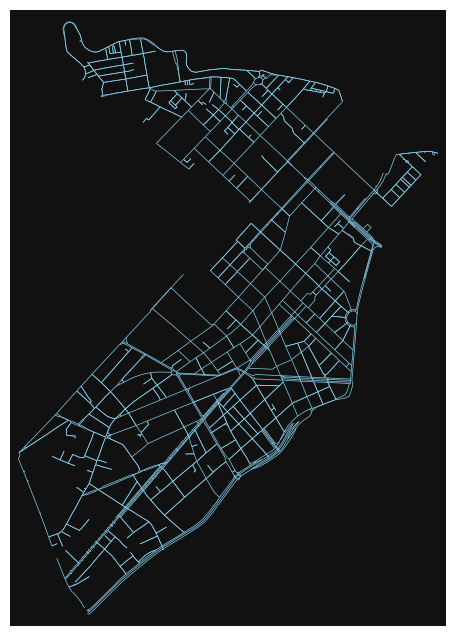

------------------------------
KẾT QUẢ PHÂN TÍCH:
- Số nút giao: 989
- Số lượng đoạn đường: 2090
- Chiều dài trung bình 1 đoạn đường: 79.03 mét
- Mật độ nút: 128.11 nút/km2


In [ ]:
!pip install osmnx networkx matplotlib
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
dia_diem = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(dia_diem, network_type='drive')
print(f"Bản đồ mạng lưới giao thông tại: {dia_diem}")
fig, ax = ox.plot_graph(G, node_size=0, edge_color='skyblue', edge_linewidth=0.5)

edges = ox.graph_to_gdfs(G, nodes=False)

so_nut = len(G.nodes)
so_canh = len(G.edges)
tong_chieu_dai = edges['length'].sum()
chieu_dai_tb = tong_chieu_dai / so_canh
dien_tich_q1 = 7.72
mat_do_nut = so_nut / dien_tich_q1

print("-" * 30)
print(f"KẾT QUẢ PHÂN TÍCH:")
print(f"- Số nút giao: {so_nut}")
print(f"- Số lượng đoạn đường: {so_canh}")
print(f"- Chiều dài trung bình 1 đoạn đường: {chieu_dai_tb:.2f} mét")
print(f"- Mật độ nút: {mat_do_nut:.2f} nút/km2")

Nhận xét bài 6
Việc sử dụng dữ liệu về các điểm giao và chiều dài đường giúp tìm ra tuyến đi ngắn nhất, từ đó giao hàng nhanh hơn và tiết kiệm năng lượng. Đồng thời, dựa vào mật độ và đặc điểm mạng lưới đường, có thể dự đoán tình trạng kẹt xe để đề xuất cải thiện hạ tầng hoặc điều chỉnh đèn giao thông, góp phần giảm ùn tắc. Qua đó, người học cũng rèn luyện tư duy toàn diện từ thu thập thông tin đến áp dụng vào thực tế, phù hợp với thời đại công nghệ.

Bai7

In [ ]:
!pip install osmnx networkx folium
import osmnx as ox
import networkx as nx
import folium
import time
khu_vuc = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(khu_vuc, network_type='drive')

dia_diem_A = "Chợ Bến Thành, TP.HCM"
dia_diem_B = "Nhà hát Thành phố, TP.HCM"

toa_do_A = ox.geocode(dia_diem_A)
toa_do_B = ox.geocode(dia_diem_B)
nut_bat_dau = ox.distance.nearest_nodes(G, toa_do_A[1], toa_do_A[0])
nut_ket_thuc = ox.distance.nearest_nodes(G, toa_do_B[1], toa_do_B[0])

#C1: Thuật toán Dijkstra
t0 = time.time()
lo_trinh_dijkstra = nx.shortest_path(G, nut_bat_dau, nut_ket_thuc, weight='length', method='dijkstra')
tg_dijkstra = time.time() - t0

# C2: Thuật toán A*
t1 = time.time()
lo_trinh_astar = nx.astar_path(G, nut_bat_dau, nut_ket_thuc, weight='length')
tg_astar = time.time() - t1

khoang_cach = nx.path_weight(G, lo_trinh_dijkstra, weight='length')

print(f"Kết quả so sánh:")
print(f"- Chiều dài quãng đường: {khoang_cach:.2f} mét")
print(f"- Thời gian Dijkstra: {tg_dijkstra:.6f} giây")
print(f"- Thời gian A*: {tg_astar:.6f} giây")

toa_do_lo_trinh = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in lo_trinh_dijkstra]

m = folium.Map(location=toa_do_A, zoom_start=15)
folium.Marker(toa_do_A, popup="Bắt đầu", icon=folium.Icon(color='green')).add_to(m)
folium.Marker(toa_do_B, popup="Kết thúc", icon=folium.Icon(color='red')).add_to(m)


folium.PolyLine(toa_do_lo_trinh, color="blue", weight=5, opacity=0.7).add_to(m)

m

Kết quả so sánh:
- Chiều dài quãng đường: 883.37 mét
- Thời gian Dijkstra: 0.001205 giây
- Thời gian A*: 0.002068 giây


1. Dijkstra:
Ưu điểm:đảm bảo tìm được đường đi ngắn nhất tuyệt đối trên đồ thị. Nó xét tất cả các hướng có khả năng xảy ra.
Nhược điểm: Tốn nhiều tài nguyên tính toán vì phải mở rộng tìm kiếm theo mọi hướng
2. A*:
Ưu điểm: Là thuật toán tìm kiếm có định hướng, A* tập trung tìm kiếm về phía đích giúp giảm số lượng nút cần kiểm tra, do đó thường nhanh hơn Dijkstra.
Nhược điểm: Hiệu quả phụ thuộc vào hàm heuristic. Nếu hàm ước tính không tốt, nó có thể không tối ưu bằng Dijkstra hoặc tốn thời gian tính toán hàm ước tính đó.
_Kết luận quản trị: Trong các hệ thống Physical AI thời gian thực như xe tự lái, thuật toán A* thường được ưu tiên vì tốc độ phản hồi nhanh, trong khi Dijkstra phù hợp hơn cho các bài toán phân tích quy hoạch cần độ chính xác tuyệt đối mà không quá khắt khe về thời gian chạy.

Bài8

In [ ]:
!pip install folium geopy
import folium
from geopy.distance import geodesic

khach_hang = {
    "Khách A": (10.7760, 106.7015),
    "Khách B": (10.7810, 106.6950),
    "Khách C": (10.7720, 106.6900)
}

danh_sach_xe = {
    "Taxi 01": (10.7790, 106.7030),
    "Taxi 02": (10.7850, 106.6980),
    "Taxi 03": (10.7700, 106.6850),
    "Taxi 04": (10.7740, 106.7050)
}

m = folium.Map(location=[10.775, 106.700], zoom_start=15)

xe_da_co_khach = set()

for ten_kh, td_kh in khach_hang.items():
    xe_phu_hop = None
    kc_nho_nhat = float('inf')

    for ten_xe, td_xe in danh_sach_xe.items():
        if ten_xe not in xe_da_co_khach:
            kc = geodesic(td_kh, td_xe).km
            if kc < kc_nho_nhat:
                kc_nho_nhat = kc
                xe_phu_hop = (ten_xe, td_xe)

    if xe_phu_hop:
        ten_xe, td_xe = xe_phu_hop
        xe_da_co_khach.add(ten_xe)

        folium.Marker(td_kh, popup=ten_kh, icon=folium.Icon(color='blue', icon='user', prefix='fa')).add_to(m)

        folium.Marker(td_xe, popup=ten_xe, icon=folium.Icon(color='red', icon='car', prefix='fa')).add_to(m)

        folium.PolyLine([td_kh, td_xe], color='green', weight=3, opacity=0.8,
                        tooltip=f"Kết nối: {kc_nho_nhat:.2f} km").add_to(m)

        print(f"Hệ thống: {ten_xe} đã được gán cho {ten_kh} (Khoảng cách: {kc_nho_nhat:.2f} km)")
m

Hệ thống: Taxi 01 đã được gán cho Khách A (Khoảng cách: 0.37 km)
Hệ thống: Taxi 02 đã được gán cho Khách B (Khoảng cách: 0.55 km)
Hệ thống: Taxi 03 đã được gán cho Khách C (Khoảng cách: 0.59 km)


**Bài 9**

In [ ]:
!pip install folium scikit-learn pandas
import pandas as pd
import folium
from sklearn.cluster import KMeans
import numpy as np


np.random.seed(42)
lat_hcm, lon_hcm = 10.776, 106.700
vi_do = lat_hcm + np.random.normal(0, 0.02, 50)
kinh_do = lon_hcm + np.random.normal(0, 0.02, 50)

df_khach = pd.DataFrame({'lat': vi_do, 'lon': kinh_do})
model_kmeans = KMeans(n_clusters=3, random_state=0)
df_khach['cum'] = model_kmeans.fit_predict(df_khach[['lat', 'lon']])

cac_tram_hub = model_kmeans.cluster_centers_
m = folium.Map(location=[lat_hcm, lon_hcm], zoom_start=13)

mau_sac = ['blue', 'green', 'purple']
for i, row in df_khach.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=mau_sac[int(row['cum'])],
        fill=True,
        popup=f"Khách hàng thuộc cụm {int(row['cum'])+1}"
    ).add_to(m)

for idx, tram in enumerate(cac_tram_hub):
    folium.Marker(
        location=[tram[0], tram[1]],
        popup=f"TRẠM TRUNG CHUYỂN {idx+1}",
        icon=folium.Icon(color='red', icon='warehouse', prefix='fa')
    ).add_to(m)

    folium.Circle(
        location=[tram[0], tram[1]],
        radius=2000,
        color='red',
        fill=True,
        fill_opacity=0.1
    ).add_to(m)
m

Việc xác định vị trí trung tâm của các nhóm khách hàng giúp đặt trạm giao nhận sao cho quãng đường đến từng khách là ngắn nhất, từ đó giảm thời gian và chi phí giao hàng. Đồng thời, doanh nghiệp chia khu vực thành các vùng phục vụ rõ ràng dựa trên mật độ đơn hàng, mỗi trạm phụ trách một khu riêng để tăng hiệu quả làm việc. Dựa vào số lượng khách trong từng vùng, họ cũng quyết định quy mô kho và nhân sự phù hợp. Khi đã có hệ thống trạm tối ưu, việc áp dụng tự động hóa như robot hay xe tự hành trong tương lai cũng trở nên dễ dàng hơn.

Bai10

In [ ]:
!pip install folium osmnx networkx
import folium
import osmnx as ox
import networkx as nx

khu_vuc = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(khu_vuc, network_type='drive')

diem_giao_thong = [
    {"ten": "Ngã sáu Phù Đổng", "td": [10.7719, 106.6914], "mat_do": 85, "mua": 0.8},
    {"ten": "Vòng xoay Quách Thị Trang", "td": [10.7712, 106.6981], "mat_do": 60, "mua": 0.2},
    {"ten": "Ngã tư Lê Duẩn - Pasteur", "td": [10.7801, 106.6975], "mat_do": 95, "mua": 0.1}
]

def tinh_nguy_co(mat_do, mua):
    diem_rui_ro = mat_do * 0.7 + (mua * 100) * 0.3
    if diem_rui_ro > 80: return "CAO", "red"
    elif diem_rui_ro > 50: return "TRUNG BÌNH", "orange"
    else: return "THẤP", "green"

tam_map = [10.775, 106.695]
m = folium.Map(location=tam_map, zoom_start=15)

for diem in diem_giao_thong:
    muc_do, mau = tinh_nguy_co(diem["mat_do"], diem["mua"])
    folium.Circle(
        location=diem["td"],
        radius=150,
        color=mau,
        fill=True,
        fill_opacity=0.4,
        popup=f"Nguy cơ: {muc_do}\nMật độ: {diem['mat_do']}%"
    ).add_to(m)

diem_A = ox.geocode("Bệnh viện Nhi Đồng 2, TP.HCM")
diem_B = ox.geocode("Chợ Bến Thành, TP.HCM")

start_node = ox.distance.nearest_nodes(G, diem_A[1], diem_A[0])
end_node = ox.distance.nearest_nodes(G, diem_B[1], diem_B[0])
lo_trinh = nx.shortest_path(G, start_node, end_node, weight='length')

toa_do_duong = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in lo_trinh]
folium.PolyLine(toa_do_duong, color="blue", weight=5, opacity=0.8, tooltip="Tuyến đường đề xuất").add_to(m)

folium.Marker(diem_A, popup="Điểm đi", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker(diem_B, popup="Điểm đến", icon=folium.Icon(color='green')).add_to(m)

m

Bai11

In [ ]:
!pip install folium pandas scikit-learn
import pandas as pd
import folium
from sklearn.linear_model import LinearRegression
import numpy as np

du_lieu = pd.DataFrame({
    'khu_vuc': ['Quận 1', 'Quận 1', 'Quận 3', 'Quận 3', 'Quận 7', 'Quận 7'],
    'lat': [10.776, 10.776, 10.782, 10.782, 10.732, 10.732],
    'lon': [106.700, 106.700, 106.695, 106.695, 106.727, 106.727],
    'gio': [8, 18, 8, 18, 8, 18],
    'so_don': [50, 120, 40, 90, 30, 100]
})


mo_hinh = LinearRegression()
X = du_lieu[['gio']]
y = du_lieu['so_don']
mo_hinh.fit(X, y)

gio_du_bao = 19
nhu_cau_du_bao = mo_hinh.predict([[gio_du_bao]])[0]


m = folium.Map(location=[10.75, 106.70], zoom_start=12)

for khu in du_lieu['khu_vuc'].unique():
    dong = du_lieu[du_lieu['khu_vuc'] == khu].iloc[0]


    du_bao_rieng = nhu_cau_du_bao * (1.2 if khu == 'Quận 1' else 0.9)

    folium.Circle(
        location=[dong['lat'], dong['lon']],
        radius=du_bao_rieng * 20, #r là tỉ lệ nhu cầu
        color='red' if du_bao_rieng > 100 else 'blue',
        fill=True,
        popup=f"{khu}: Dự báo {int(du_bao_rieng)} đơn lúc {gio_du_bao}h"
    ).add_to(m)

m

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Bản đồ nhu cầu giúp doanh nghiệp thấy rõ nơi nào cần nhiều nhân lực hơn, từ đó điều phối shipper từ khu vực ít đơn sang khu vực đông đơn trước giờ cao điểm để cân bằng cung, cầu. Đồng thời, hệ thống có thể tự điều chỉnh giá tại các khu vực nhu cầu cao để thu hút thêm tài xế và giảm bớt đơn không cần gấp. Việc nắm được nhu cầu theo thời gian cũng giúp sắp xếp ca làm và vận hành hiệu quả hơn. Về lâu dài, nếu một khu vực luôn quá tải, doanh nghiệp có thể mở thêm trạm hoặc kho -> rút ngắn tg giao hàng

Bai12

In [ ]:
!pip install folium geopy
import folium
from geopy.distance import geodesic
import itertools

kho_hang = {"Kho Quận 1": (10.776, 106.700), "Kho Quận 7": (10.732, 106.727)}
khach_hang = {
    "K1": (10.780, 106.710), "K2": (10.790, 106.705), "K3": (10.770, 106.690), # Gầnq1
    "K4": (10.735, 106.735), "K5": (10.725, 106.715), "K6": (10.745, 106.740)  # Gần Q7
}

cum_kho = {ten_kho: [] for ten_kho in kho_hang}
for ten_kh, td_kh in khach_hang.items():
    kho_gan_nhat = min(kho_hang.keys(), key=lambda k: geodesic(td_kh, kho_hang[k]).km)
    cum_kho[kho_gan_nhat].append((ten_kh, td_kh))


def tim_duong_toi_uu(toa_do_kho, ds_khach):
    min_dist = float('inf')
    best_route = None

    for perm in itertools.permutations(ds_khach):
        route = [toa_do_kho] + [p[1] for p in perm] + [toa_do_kho]
        dist = sum(geodesic(route[i], route[i+1]).km for i in range(len(route)-1))
        if dist < min_dist:
            min_dist = dist
            best_route = route
    return best_route, min_dist


ban_do = folium.Map(location=[10.75, 106.71], zoom_start=13)
tong_kc_toi_uu = 0
tong_kc_mac_dinh = 0

mau_tuyen = ["blue", "green"]

for i, (ten_kho, ds_kh) in enumerate(cum_kho.items()):
    td_kho = kho_hang[ten_kho]
    folium.Marker(td_kho, popup=ten_kho, icon=folium.Icon(color='red', icon='warehouse', prefix='fa')).add_to(ban_do)

    #đường tối ưu
    lo_trinh, kc_u = tim_duong_toi_uu(td_kho, ds_kh)
    tong_kc_toi_uu += kc_u


    lo_trinh_goc = [td_kho] + [p[1] for p in ds_kh] + [td_kho]
    kc_goc = sum(geodesic(lo_trinh_goc[j], lo_trinh_goc[j+1]).km for j in range(len(lo_trinh_goc)-1))
    tong_kc_mac_dinh += kc_goc


    folium.PolyLine(lo_trinh, color=mau_tuyen[i], weight=4, opacity=0.7, tooltip=f"Tuyến {ten_kho}").add_to(ban_do)
    for ten_kh, td_kh in ds_kh:
        folium.Marker(td_kh, popup=f"{ten_kh} (Kho: {ten_kho})").add_to(ban_do)


hieu_qua = ((tong_kc_mac_dinh - tong_kc_toi_uu) / tong_kc_mac_dinh) * 100
print(f"Tổng quãng đường KHÔNG tối ưu: {tong_kc_mac_dinh:.2f} km")
print(f"Tổng quãng đường TỐI ƯU: {tong_kc_toi_uu:.2f} km")
print(f"HIỆU QUẢ CẢI THIỆN: {hieu_qua:.2f}%")

ban_do

Tổng quãng đường KHÔNG tối ưu: 15.37 km
Tổng quãng đường TỐI ƯU: 13.66 km
HIỆU QUẢ CẢI THIỆN: 11.16%


Bai13

In [ ]:
import folium
trung_tam = [10.776, 106.700]
m = folium.Map(location=trung_tam, zoom_start=14)

kho = [10.776, 106.700]
khach_hang = [10.785, 106.710]

folium.Marker(kho, popup="Kho Tổng", icon=folium.Icon(color="red")).add_to(m)
folium.Marker(khach_hang, popup="Khách Hàng A", icon=folium.Icon(color="blue")).add_to(m)

folium.Circle(
    location=kho,
    radius=2000,
    color="green",
    fill=True,
    fill_opacity=0.1,
    tooltip="Vùng phục vụ chiến lược"
).add_to(m)

lo_trinh = [kho, khach_hang]
folium.PolyLine(lo_trinh, color="orange", weight=5, tooltip="Tuyến đường tối ưu").add_to(m)

# Hiển thị dashboard
m

**Bài 14**

In [ ]:
import folium
import random
from geopy.distance import geodesic

vi_tri_xe = [10.776, 106.701]
ban_do = folium.Map(location=vi_tri_xe, zoom_start=14)
thoi_gian_tong = 0


for i in range(1, 6):
    vi_tri_cu = vi_tri_xe


    vi_tri_xe = [vi_tri_cu[0] + random.uniform(0.002, 0.005),
                 vi_tri_cu[1] + random.uniform(0.002, 0.005)]
    thoi_gian_buoc = random.randint(5, 15) # phút
    thoi_gian_tong += thoi_gian_buoc


    folium.PolyLine(
        locations=[vi_tri_cu, vi_tri_xe],
        color="blue",
        weight=5,
        opacity=0.8,
        popup=f"Đoạn {i}: +{thoi_gian_buoc} phút (Tổng: {thoi_gian_tong}p)"
    ).add_to(ban_do)
    folium.CircleMarker(
        location=vi_tri_xe,
        radius=3,
        color="red",
        popup=f"Mốc T{i}: {thoi_gian_tong}p"
    ).add_to(ban_do)

    print(f"Bước {i}: Cập nhật vị trí {vi_tri_xe} tại phút thứ {thoi_gian_tong}")

folium.Marker(
    location=vi_tri_xe,
    popup=f"Vị trí xe hiện tại (T+{thoi_gian_tong}p)",
    icon=folium.Icon(color="red", icon="car", prefix="fa")
).add_to(ban_do)

ban_do

Bước 1: Cập nhật vị trí [10.780913989096971, 106.70365400908108] tại phút thứ 7
Bước 2: Cập nhật vị trí [10.783068084195083, 106.70596492331723] tại phút thứ 16
Bước 3: Cập nhật vị trí [10.788018382235677, 106.71032105852461] tại phút thứ 30
Bước 4: Cập nhật vị trí [10.791378112886358, 106.71409478807146] tại phút thứ 41
Bước 5: Cập nhật vị trí [10.79399363172572, 106.71629600695313] tại phút thứ 56


**Bài 15**
Trình bày bài toán
Vấn đề: Doanh nghiệp có nhiều khách hàng phân tán tại TP.HCM. Việc giao hàng từ một kho lớn ở xa gây tốn kém thời gian + chi phí.
Mục tiêu:
Dùng AI phân cụm vị trí khách hàng để tìm ra vị trí đặt Kho trung chuyểntối ưu nhất
Tối ưu hóa thứ tự giao hàng từ Kho trung chuyển đến các khách hàng để shipper di chuyển ít nhất.
1) Data
Danh sách tọa độ (Vĩ độ, Kinh độ) của các khách hàng tại khu vực Quận 1 và Quận 3, TP.HCM.
Trạng thái đơn hàng (đã giao hay chưa)
2) Phương pháp AI
Phân cụm: Sử dụng thuật toán K-Means để xác định trọng tâm của nhóm khách hàng. Điểm trọng tâm này chính là vị trí đặt kho lý tưởng.
Tối ưu hóa: Sử dụng logic OR-Tools hoặc Permutation để giải bài toán người giao hàng, tìm lộ trình ngắn nhất đi qua các điểm.

In [ ]:
import folium
import numpy as np
from sklearn.cluster import KMeans
from geopy.distance import geodesic
import itertools

toa_do_khach = np.array([
    [10.775, 106.700], [10.780, 106.695], [10.772, 106.690],
    [10.785, 106.710], [10.770, 106.705], [10.765, 106.698]
])

ai_phan_cum = KMeans(n_clusters=1, n_init=10).fit(toa_do_khach)
vi_tri_kho = ai_phan_cum.cluster_centers_[0]

#optimize
khach_hang_list = toa_do_khach.tolist()
min_quang_duong = float('inf')
lo_trinh_tot_nhat = []

for hoan_vi in itertools.permutations(khach_hang_list):
    duong_di = [vi_tri_kho.tolist()] + list(hoan_vi)
    tong_d = sum(geodesic(duong_di[i], duong_di[i+1]).km for i in range(len(duong_di)-1))
    if tong_d < min_quang_duong:
        min_quang_duong = tong_d
        lo_trinh_tot_nhat = duong_di

ban_do = folium.Map(location=vi_tri_kho, zoom_start=15)


folium.Circle(vi_tri_kho, radius=1000, color='green', fill=True, opacity=0.1, tooltip="Vùng phục vụ Hub").add_to(ban_do)

folium.Marker(vi_tri_kho, popup="Hub AI Gợi Ý", icon=folium.Icon(color='red', icon='home')).add_to(ban_do)

folium.PolyLine(lo_trinh_tot_nhat, color="blue", weight=4, opacity=0.8, tooltip="Lộ trình tối ưu").add_to(ban_do)

for i, diem in enumerate(khach_hang_list):
    folium.Marker(diem, popup=f"Khách hàng {i+1}", icon=folium.Icon(color='blue', icon='user', prefix='fa')).add_to(ban_do)

print(f"Vị trí kho tối ưu: {vi_tri_kho}")
print(f"Tổng quãng đường tối ưu: {min_quang_duong:.2f} km")
ban_do

Vị trí kho tối ưu: [ 10.7745     106.69966667]
Tổng quãng đường tối ưu: 5.73 km
